# Autoencoder Baseline -- One-Class Classification

## Ziel

Wir zeigen dem Modell **nur gute Ruderschlaege**. Danach entscheidet es:
> Ist dieser neue Schlag aehnlich genug zu dem, was ich gelernt habe?

Das ist ein **One-Class Classification** Problem (auch: Anomalieerkennung).
- Klasse 0 (Normal): guter Schlag
- Alles andere: schlechter Schlag (Anomalie)

---

## Was ist ein Autoencoder?

Ein Autoencoder ist ein neuronales Netz mit zwei Teilen:

```
Input (Sequenz) --> [ENCODER] --> Bottleneck --> [DECODER] --> Rekonstruktion
```

- **Encoder**: komprimiert die Eingabe auf eine kleine Repraesentation (Bottleneck)
- **Decoder**: versucht, die Eingabe aus dem Bottleneck zu rekonstruieren
- **Verlust**: Mean Squared Error zwischen Input und Rekonstruktion

Das Modell lernt, **gute Schlaege gut zu rekonstruieren**. Fuer schlechte Schlaege ist der Rekonstruktionsfehler hoch -- das ist das Erkennungssignal.

---

## LSTM vs. Conv1D

| | LSTM | Conv1D |
|---|---|---|
| **Was es tut** | Merkt sich vergangene Schritte (Gedaechtnis) | Sucht lokale Muster im Zeitfenster |
| **Gut fuer** | Rhythmus, Langzeit-Abhaengigkeiten | Kurze charakteristische Bewegungsmuster |
| **Geschwindigkeit** | Langsamer | Schneller |
| **Wir waehlen** | Ja | Nein |

**LSTM** ist besser geeignet, weil der Gesamtrhythmus (Vorlage -> Antrieb -> Endzug) ueber die ganze Sequenz wichtig ist.


In [178]:
!pip install tensorflow


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [179]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)
import tensorflow as tf
from tensorflow import keras 
from tensorflow.keras import layers

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'requirements.txt').exists()
)
NORM_DIR = PROJECT_ROOT / '1_DatasetCharacteristics' / 'landmarks' / 'normalized'

print('TensorFlow:', tf.__version__) 
print('Project root:', PROJECT_ROOT)

TensorFlow: 2.21.0
Project root: /Users/clarabrilke/ML projects/ML-project


In [180]:
EXCLUDE_COLS = {'phase', 'GOOD', 'BAD'}

def resample_seq(seq, target_len):
    """Interpoliert eine Sequenz variabler Laenge auf target_len Frames."""
    x_old = np.linspace(0, 1, len(seq))
    x_new = np.linspace(0, 1, target_len)
    return interp1d(x_old, seq, axis=0)(x_new)

def load_strokes_for_video(video_stem):
    lm_path     = NORM_DIR / f'{video_stem}-landmarks-norm_10fps.csv'
    stroke_path = NORM_DIR / f'{video_stem}-strokes.csv'
    landmarks   = pd.read_csv(lm_path)
    strokes     = pd.read_csv(stroke_path)
    feature_cols = [c for c in landmarks.columns if c not in EXCLUDE_COLS]
    X = landmarks[feature_cols].values

    # strokes.csv speichert Frame-Nummern aus dem Originalvideo (~30fps).
    # Die landmarks-Datei ist auf 10fps heruntergesampelt (~Faktor 3).
    # Deshalb muessen die Indizes durch den fps-Faktor geteilt werden.
    fps_ratio = max(1, round(strokes['endzug_end'].max() / len(landmarks)))

    seqs = []
    for _, row in strokes.iterrows():
        start = int(row['endzug_start'] / fps_ratio)
        end   = int(row['endzug_end']   / fps_ratio)
        seq   = X[start:end]
        if len(seq) >= 10:
            seqs.append(seq)
    return seqs, feature_cols, fps_ratio

# --- Alle Stroke-Dateien automatisch einlesen ---
stroke_files = sorted(NORM_DIR.glob('*-strokes.csv'))
# stroke_files = [f for f in stroke_files if not f.stem.startswith('sim')]

print(f'Gefundene Videos: {len(stroke_files)}')
for f in stroke_files:
    label = 'BAD ' if 'BAD' in f.stem.upper() else 'GOOD'
    print(f'  [{label}]  {f.stem}')

# TARGET_LEN = Median der Schlaglaengen (in 10fps-Frames) ueber alle Videos
all_lengths = []
for sf in stroke_files:
    lm = pd.read_csv(NORM_DIR / f'{sf.stem.replace("-strokes", "")}-landmarks-norm_10fps.csv')
    st = pd.read_csv(sf)
    fps_ratio = max(1, round(st['endzug_end'].max() / len(lm)))
    lengths = ((st['endzug_end'] - st['endzug_start']) / fps_ratio).round().astype(int)
    all_lengths.extend(lengths.tolist())

TARGET_LEN = int(np.median(all_lengths))
print(f'\nSchlaglaengen (10fps) -- min: {min(all_lengths)}  median: {TARGET_LEN}  max: {max(all_lengths)}')
print(f'TARGET_LEN = {TARGET_LEN} Frames')

# --- Sequenzen laden und resamplen ---
good_seqs, bad_seqs = [], []
feature_cols = None

for sf in stroke_files:
    video_stem = sf.stem.replace('-strokes', '')
    seqs, fcols, ratio = load_strokes_for_video(video_stem)
    if feature_cols is None:
        feature_cols = fcols
    resampled = [resample_seq(s, TARGET_LEN) for s in seqs]
    if 'BAD' in video_stem.upper():
        bad_seqs.extend(resampled)
        print(f'  {video_stem}: {len(seqs)} Schlaege geladen (fps_ratio={ratio})')
    else:
        good_seqs.extend(resampled)
        print(f'  {video_stem}: {len(seqs)} Schlaege geladen (fps_ratio={ratio})')

X_good_seq = np.array(good_seqs)
X_bad_seq  = np.array(bad_seqs)

print(f'\nGute Schlaege:      {X_good_seq.shape}  (n_sequenzen, frames, features)')
print(f'Schlechte Schlaege: {X_bad_seq.shape}')

Gefundene Videos: 10
  [BAD ]  cla-BAD-2-strokes
  [BAD ]  cla-BAD-strokes
  [GOOD]  cla-GOOD-fast-strokes
  [GOOD]  cla-GOOD-slow-2-strokes
  [GOOD]  cla-GOOD-slow-strokes
  [GOOD]  mar-GOOD-fast-strokes
  [GOOD]  mar-GOOD-slow-strokes
  [GOOD]  sim-GOOD-fast-strokes
  [GOOD]  sim-GOOD-slow-strokes
  [GOOD]  sim-GOOD-slow2-strokes

Schlaglaengen (10fps) -- min: 18  median: 26  max: 34
TARGET_LEN = 26 Frames
  cla-BAD-2: 59 Schlaege geladen (fps_ratio=3)
  cla-BAD: 20 Schlaege geladen (fps_ratio=3)
  cla-GOOD-fast: 87 Schlaege geladen (fps_ratio=3)
  cla-GOOD-slow-2: 33 Schlaege geladen (fps_ratio=3)
  cla-GOOD-slow: 68 Schlaege geladen (fps_ratio=3)
  mar-GOOD-fast: 61 Schlaege geladen (fps_ratio=3)
  mar-GOOD-slow: 50 Schlaege geladen (fps_ratio=3)
  sim-GOOD-fast: 45 Schlaege geladen (fps_ratio=3)
  sim-GOOD-slow: 76 Schlaege geladen (fps_ratio=3)
  sim-GOOD-slow2: 11 Schlaege geladen (fps_ratio=3)

Gute Schlaege:      (431, 26, 66)  (n_sequenzen, frames, features)
Schlechte Schlaeg

## Normalisierung

Beide Datensaetze wurden durch die gleiche koerperrelative Mediapipe-Normalisierung verarbeitet.
Ein zusaetzlicher StandardScaler ist nicht mehr noetig -- die Skalen sind bereits vergleichbar.


In [181]:
# Daten sind bereits durch Mediapipe-Normalisierung skaliert -- kein StandardScaler noetig.
print('Gute Schlaege   -- Mittelwert:', X_good_seq.mean().round(4), 'Std:', X_good_seq.std().round(4))
print('Schlechte Schlaege -- Mittelwert:', X_bad_seq.mean().round(4), 'Std:', X_bad_seq.std().round(4))

Gute Schlaege   -- Mittelwert: -0.4573 Std: 0.6426
Schlechte Schlaege -- Mittelwert: -0.4498 Std: 0.6214


## Segmentierung an echten Schlaggrenzen

Statt eines gleitenden Fensters wird jeder Schlag exakt an seinen echten Grenzen aus den Stroke-Dateien ausgeschnitten:

```
endzug_start --> endzug_end   = ein vollstaendiger Schlag
```

Da Schlaege unterschiedlich lang sind (z.B. 67–78 Frames), wird jede Sequenz per linearer Interpolation auf **TARGET_LEN** Frames resamplet. Das hat zwei Vorteile:
- Das LSTM bekommt immer gleichlange Eingaben
- Schnelle und langsame Schlaege sind direkt vergleichbar (Geschwindigkeit wird herausnormalisiert)

Neue Videos mit Stroke-Dateien im `normalized/`-Ordner werden **automatisch** erkannt.

In [182]:
# Sequenzen wurden bereits in cell-02 geladen -- hier nur zur Uebersicht
print(f'Gute Sequenzen:      {X_good_seq.shape}  (n_sequenzen, frames, features)')
print(f'Schlechte Sequenzen: {X_bad_seq.shape}')

Gute Sequenzen:      (431, 26, 66)  (n_sequenzen, frames, features)
Schlechte Sequenzen: (79, 26, 66)


In [183]:
# Train / Validation Split -- nur gute Sequenzen
# Shuffle entlang der Stroke-Achse (axis=0), damit alle Videos gleichmaessig verteilt sind
stroke_indices = np.random.permutation(len(X_good_seq))
X_good_shuffled = X_good_seq[stroke_indices]

n_train = int(len(X_good_shuffled) * 0.8)
X_train = X_good_shuffled[:n_train]
X_val   = X_good_shuffled[n_train:]

print(f'Training:   {X_train.shape[0]} Sequenzen')
print(f'Validation: {X_val.shape[0]} Sequenzen')
print(f'Schlechte (nur Evaluation): {X_bad_seq.shape[0]} Sequenzen')

Training:   344 Sequenzen
Validation: 87 Sequenzen
Schlechte (nur Evaluation): 79 Sequenzen


## LSTM Autoencoder -- Architektur

```
Input: (24 Frames x 66 Features)
        |
  LSTM(128)         <-- verarbeitet die Sequenz, Ausgabe nur letzter Schritt
        |
  Dense(32)         <-- Bottleneck: komprimierte Repraesentation des Schlags
        |
  RepeatVector(24)  <-- dupliziert den Bottleneck fuer jeden Zeitschritt
        |
  LSTM(128, return_sequences=True)  <-- rekonstruiert die Sequenz
        |
  TimeDistributed(Dense(66))  <-- ein Output-Vektor pro Zeitschritt
        |
Output: (24 Frames x 66 Features) -- Rekonstruktion
```

**Loss**: MSE zwischen Input und Rekonstruktion.  
**Anomalie-Score**: mittlerer MSE ueber alle Zeitschritte einer Sequenz.


In [184]:
n_timesteps = TARGET_LEN
n_features  = X_train.shape[2]
LATENT_DIM  = 32

def build_lstm_autoencoder(timesteps, features, latent_dim):
    inputs = keras.Input(shape=(timesteps, features), name='input')

    # Encoder
    x = layers.LSTM(128, return_sequences=False, name='encoder_lstm')(inputs)
    bottleneck = layers.Dense(latent_dim, activation='relu', name='bottleneck')(x)

    # Decoder
    x = layers.RepeatVector(timesteps, name='repeat')(bottleneck)
    x = layers.LSTM(128, return_sequences=True, name='decoder_lstm')(x)
    outputs = layers.TimeDistributed(layers.Dense(features), name='output')(x)

    return keras.Model(inputs, outputs, name='LSTM_Autoencoder')

model = build_lstm_autoencoder(n_timesteps, n_features, LATENT_DIM)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "LSTM_Autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 26, 66)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_lstm (LSTM)             │ (None, 128)            │        99,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat (RepeatVector)           │ (None, 26, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_lstm (LSTM)             │ (None, 26, 128)        │        82,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (TimeDistributed)        │ (None, 26, 66)         │         8,514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 194,914 (761.38 KB)

 Trainable params: 194,914 (761.38 KB)

 Non-trainable params: 0 (0.00 B)

In [185]:
EPOCHS     = 50
BATCH_SIZE = 32

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,            # Autoencoder: Input = Target
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.3805 - val_loss: 0.1353
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.1003 - val_loss: 0.0927
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0798 - val_loss: 0.0748
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0687 - val_loss: 0.0668
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0610 - val_loss: 0.0597
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0555 - val_loss: 0.0555
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0514 - val_loss: 0.0489
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0398 - val_loss: 0.0418
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0287 - val_loss: 0.0201
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0171 - val_loss: 0.0140
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0122 - val_loss: 0.0111
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0

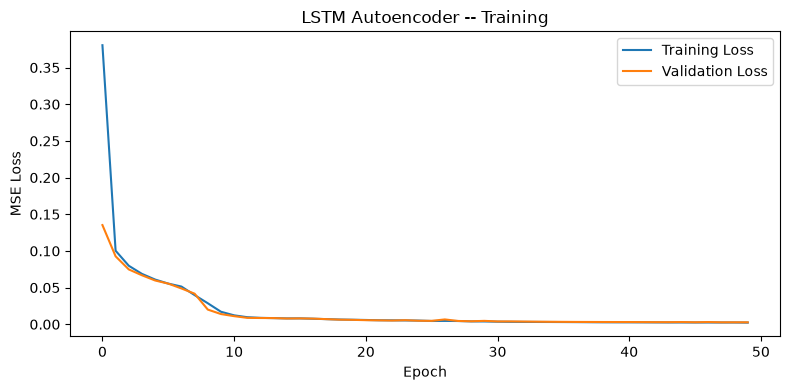

In [186]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder -- Training')
ax.legend()
plt.tight_layout()
plt.show()


## Schwellenwert (Threshold)

Wir berechnen den Rekonstruktionsfehler (MSE) fuer alle Trainingssequenzen.
Als Schwellenwert waehlen wir das **95. Perzentil** der Trainings-Fehler:

> Sequenzen mit MSE > Threshold --> **schlechter Schlag**

Der Threshold kann angepasst werden (z.B. 99. Perzentil = strenger, weniger False Positives).

In [187]:
def reconstruction_error(model, X):
    X_pred = model.predict(X, verbose=0)
    return np.mean(np.square(X - X_pred), axis=(1, 2))

train_errors = reconstruction_error(model, X_train)
val_errors   = reconstruction_error(model, X_val)
bad_errors   = reconstruction_error(model, X_bad_seq)

THRESHOLD_PERCENTILE = 95
threshold = np.percentile(train_errors, THRESHOLD_PERCENTILE)

print(f'Threshold ({THRESHOLD_PERCENTILE}. Perzentil der Trainingsfehler): {threshold:.6f}')
print(f'Mittlerer Fehler -- Training:   {train_errors.mean():.6f}')
print(f'Mittlerer Fehler -- Validation: {val_errors.mean():.6f}')
print(f'Mittlerer Fehler -- Schlechte:  {bad_errors.mean():.6f}')


Threshold (95. Perzentil der Trainingsfehler): 0.003396
Mittlerer Fehler -- Training:   0.002203
Mittlerer Fehler -- Validation: 0.002704
Mittlerer Fehler -- Schlechte:  0.011733


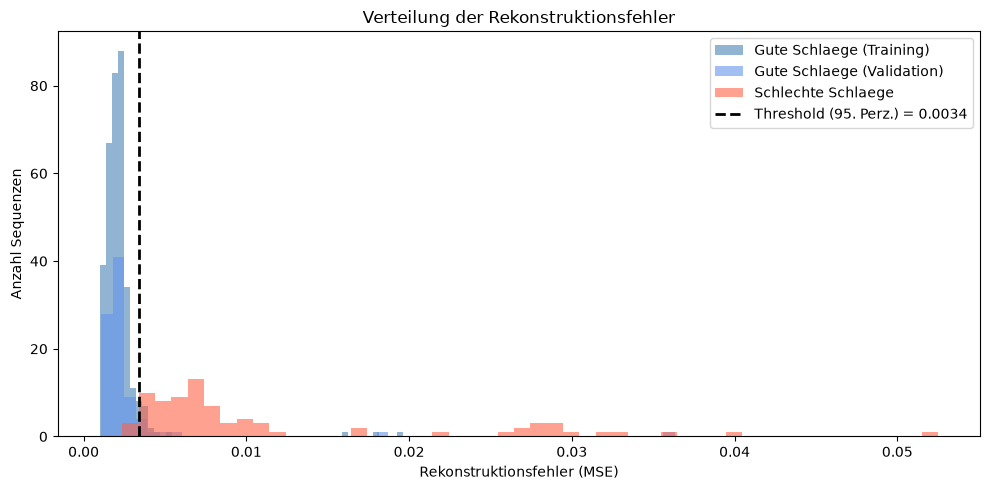

In [188]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_errors, bins=50, alpha=0.6, label='Gute Schlaege (Training)',  color='steelblue')
ax.hist(val_errors,   bins=50, alpha=0.6, label='Gute Schlaege (Validation)', color='cornflowerblue')
ax.hist(bad_errors,   bins=50, alpha=0.6, label='Schlechte Schlaege',         color='tomato')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold ({THRESHOLD_PERCENTILE}. Perz.) = {threshold:.4f}')
ax.set_xlabel('Rekonstruktionsfehler (MSE)')
ax.set_ylabel('Anzahl Sequenzen')
ax.set_title('Verteilung der Rekonstruktionsfehler')
ax.legend()
plt.tight_layout()
plt.show()


## Evaluation

Wir kombinieren Validierungs-Sequenzen (gut) und schlechte Sequenzen:
- **Label 0** = gut (Fehler <= Threshold)
- **Label 1** = schlecht (Fehler > Threshold)

| Metrik | Bedeutung |
|---|---|
| **Recall (schlecht)** | Wie viele schlechte Schlaege erkennen wir? |
| **Precision (schlecht)** | Wie oft haben wir Recht, wenn wir 'schlecht' sagen? |
| **ROC-AUC** | Trennschaerfe unabhaengig vom Threshold |


ROC-AUC: 0.9678  (unabhaengig vom Threshold)

  Durchgang 1: 95%-Faustregel  (Threshold = 0.003396)
              precision    recall  f1-score   support

         Gut       0.96      0.92      0.94        87
    Schlecht       0.92      0.96      0.94        79

    accuracy                           0.94       166
   macro avg       0.94      0.94      0.94       166
weighted avg       0.94      0.94      0.94       166

  Durchgang 2: F1-optimal  (Threshold = 0.003554)
              precision    recall  f1-score   support

         Gut       0.95      0.93      0.94        87
    Schlecht       0.93      0.95      0.94        79

    accuracy                           0.94       166
   macro avg       0.94      0.94      0.94       166
weighted avg       0.94      0.94      0.94       166



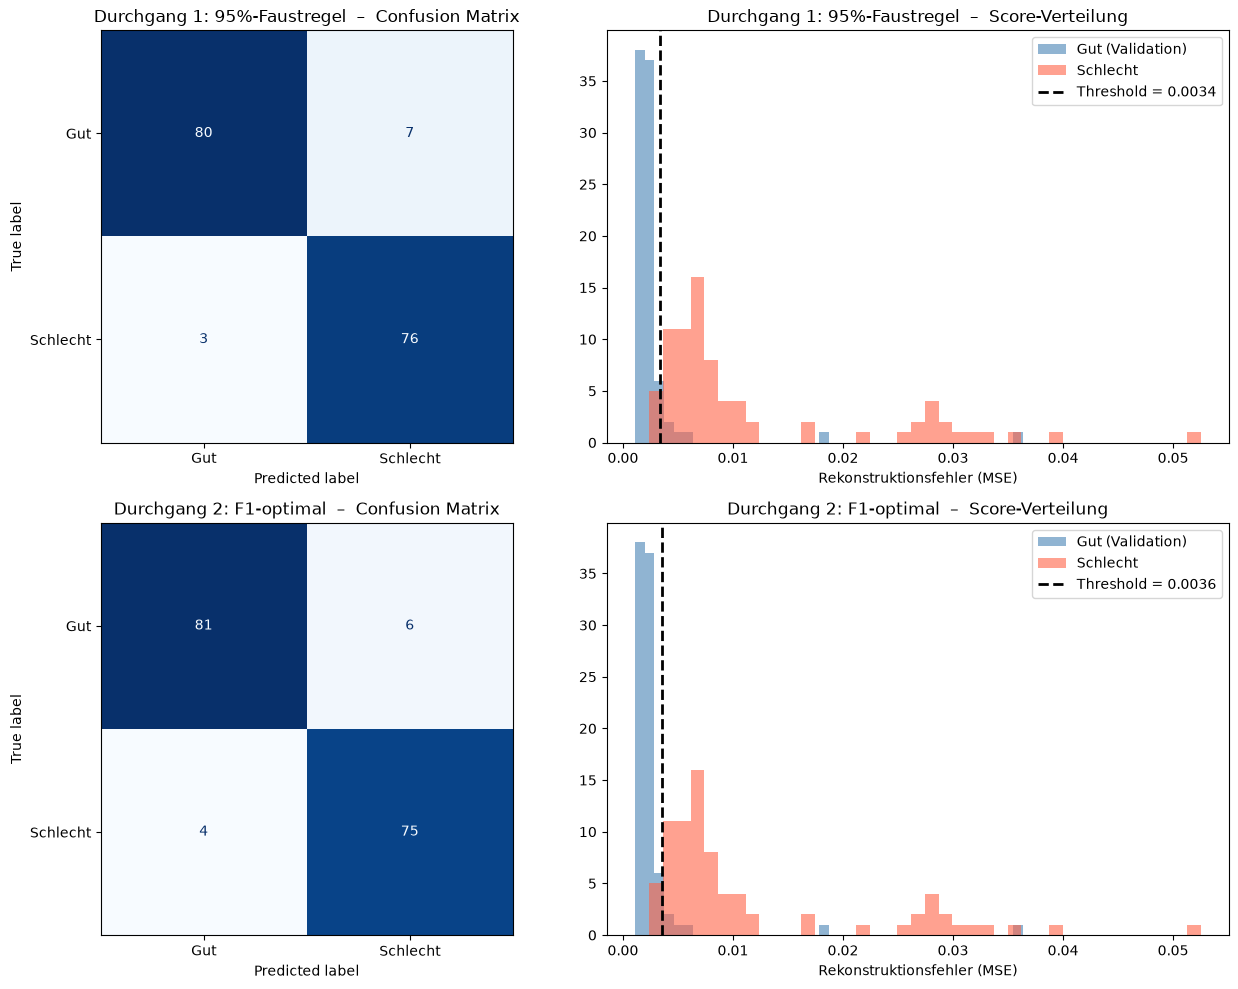

In [189]:
from sklearn.metrics import precision_recall_curve

y_scores = np.concatenate([val_errors, bad_errors])
y_true   = np.array([0] * len(val_errors) + [1] * len(bad_errors))

# F1-optimalen Threshold einmalig berechnen
precision_c, recall_c, thr_c = precision_recall_curve(y_true, y_scores, pos_label=1)
f1_c         = 2 * (precision_c * recall_c) / (precision_c * recall_c + 1e-8)
threshold_f1 = thr_c[np.argmax(f1_c)]

auc = roc_auc_score(y_true, y_scores)
print(f'ROC-AUC: {auc:.4f}  (unabhaengig vom Threshold)\n')

# --- Loop: erst Faustregel, dann F1-optimal ---
configs = [
    ('95%-Faustregel', threshold),
    ('F1-optimal',     threshold_f1),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

for i, (label, thr) in enumerate(configs):
    y_pred = (y_scores > thr).astype(int)

    print(f'{"=" * 50}')
    print(f'  Durchgang {i+1}: {label}  (Threshold = {thr:.6f})')
    print(f'{"=" * 50}')
    print(classification_report(y_true, y_pred, target_names=['Gut', 'Schlecht']))

    ConfusionMatrixDisplay(
        confusion_matrix(y_true, y_pred),
        display_labels=['Gut', 'Schlecht']
    ).plot(ax=axes[i, 0], colorbar=False, cmap='Blues')
    axes[i, 0].set_title(f'Durchgang {i+1}: {label}  –  Confusion Matrix')

    axes[i, 1].hist(val_errors, bins=40, alpha=0.6, label='Gut (Validation)', color='steelblue')
    axes[i, 1].hist(bad_errors, bins=40, alpha=0.6, label='Schlecht',          color='tomato')
    axes[i, 1].axvline(thr, color='black', linestyle='--', linewidth=2,
                       label=f'Threshold = {thr:.4f}')
    axes[i, 1].set_xlabel('Rekonstruktionsfehler (MSE)')
    axes[i, 1].set_title(f'Durchgang {i+1}: {label}  –  Score-Verteilung')
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

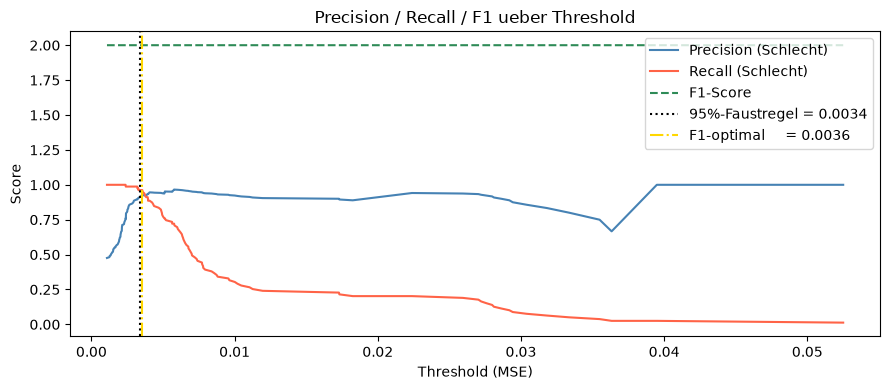

In [190]:
# Precision-Recall-Kurve zur Visualisierung (verwendet Variablen aus der Evaluation oben)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(thr_c, precision_c[:-1], label='Precision (Schlecht)', color='steelblue')
ax.plot(thr_c, recall_c[:-1],    label='Recall (Schlecht)',    color='tomato')
ax.plot(thr_c, f1_c[:-1],        label='F1-Score',             color='seagreen', linestyle='--')
ax.axvline(threshold,     color='black', linestyle=':',
           label=f'95%-Faustregel = {threshold:.4f}')
ax.axvline(threshold_f1,  color='gold',  linestyle='-.',
           label=f'F1-optimal     = {threshold_f1:.4f}')
ax.set_xlabel('Threshold (MSE)')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 ueber Threshold')
ax.legend()
plt.tight_layout()
plt.show()

In [191]:
print('=' * 60)
print('  ZUSAMMENFASSUNG')
print('=' * 60)
print(f'\n  ROC-AUC: {auc:.4f}  (unabhaengig vom Threshold)\n')
print(f'  {"":22}  {"Threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>6}')
print(f'  {"-"*22}  {"-"*10}  {"-"*10}  {"-"*8}  {"-"*6}')

for label, thr in [('95%-Faustregel', threshold), ('F1-optimal', threshold_f1)]:
    y_pred = (y_scores > thr).astype(int)
    rep = classification_report(y_true, y_pred, target_names=['Gut', 'Schlecht'], output_dict=True)
    p   = rep['Schlecht']['precision']
    r   = rep['Schlecht']['recall']
    f1  = rep['Schlecht']['f1-score']
    print(f'  {label:22}  {thr:>10.6f}  {p:>10.2%}  {r:>8.2%}  {f1:>6.4f}')

print('=' * 60)

  ZUSAMMENFASSUNG

  ROC-AUC: 0.9678  (unabhaengig vom Threshold)

                           Threshold   Precision    Recall      F1
  ----------------------  ----------  ----------  --------  ------
  95%-Faustregel            0.003396      91.57%    96.20%  0.9383
  F1-optimal                0.003554      92.59%    94.94%  0.9375


---

## Hyperparameter-Tuning mit Optuna

Optuna sucht automatisch nach der besten Kombination aus:

| Hyperparameter | Suchraum |
|---|---|
| `latent_dim` | 8, 16, 32, 64 |
| `lstm_units` | 64, 128, 256 |
| `dropout` | 0.0 – 0.4 |
| `lr` | 1e-4 – 1e-2 (log) |

**Zielmetrik**: ROC-AUC auf Validation + Schlechte Schlaege (maximieren).  
30 Trials, je ~50 Epochen mit Early Stopping.

In [195]:
!pip install optuna -q

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    latent_dim = trial.suggest_categorical('latent_dim', [8, 16, 32, 64])
    lstm_units = trial.suggest_categorical('lstm_units', [64, 128, 256])
    dropout    = trial.suggest_float('dropout', 0.0, 0.4, step=0.1)
    lr         = trial.suggest_float('lr', 1e-4, 1e-2, log=True)

    inputs     = keras.Input(shape=(n_timesteps, n_features))
    x          = layers.LSTM(lstm_units, return_sequences=False)(inputs)
    if dropout > 0:
        x      = layers.Dropout(dropout)(x)
    bottleneck = layers.Dense(latent_dim, activation='relu')(x)
    x          = layers.RepeatVector(n_timesteps)(bottleneck)
    x          = layers.LSTM(lstm_units, return_sequences=True)(x)
    if dropout > 0:
        x      = layers.Dropout(dropout)(x)
    outputs    = layers.TimeDistributed(layers.Dense(n_features))(x)
    m          = keras.Model(inputs, outputs)
    m.compile(optimizer=keras.optimizers.Adam(lr), loss='mse')

    m.fit(
        X_train, X_train,
        validation_data=(X_val, X_val),
        epochs=50, batch_size=32,
        callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
        verbose=0
    )

    def recon_err(X):
        return np.mean(np.square(X - m.predict(X, verbose=0)), axis=(1, 2))

    y_sc = np.concatenate([recon_err(X_val), recon_err(X_bad_seq)])
    y_tr = np.array([0] * len(X_val) + [1] * len(X_bad_seq))
    return roc_auc_score(y_tr, y_sc)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f'\nBestes Trial:  ROC-AUC = {study.best_value:.4f}')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Best trial: 28. Best value: 0.969591: 100%|██████████| 30/30 [04:55<00:00,  9.84s/it]


Bestes Trial:  ROC-AUC = 0.9696
  latent_dim: 16
  lstm_units: 128
  dropout: 0.0
  lr: 0.0027279298535788435


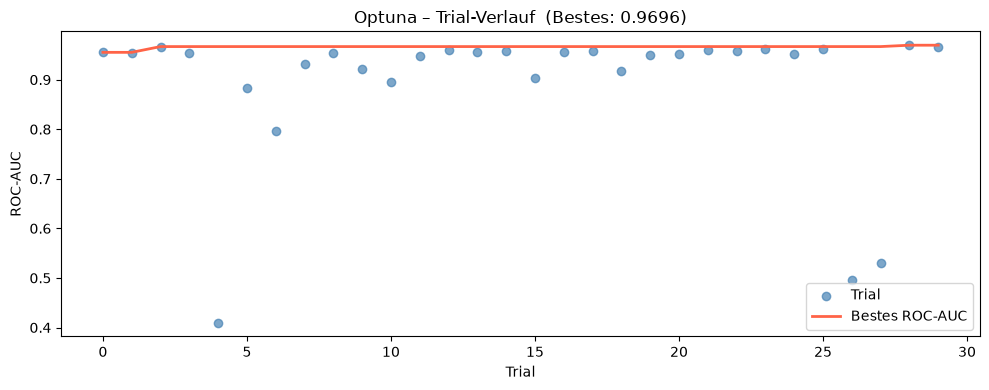


Top-5 Trials:
   value  params_dropout  params_latent_dim  params_lr  params_lstm_units
0.969591             0.0                 16   0.002728                128
0.966827             0.3                 64   0.001700                128
0.965663             0.3                 16   0.001088                256
0.962171             0.0                 16   0.001023                128
0.961589             0.0                 16   0.002583                128


In [196]:
# Trial-Verlauf visualisieren
trials_df = study.trials_dataframe()

fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(trials_df.index, trials_df['value'], alpha=0.7, color='steelblue', label='Trial')
ax.plot(trials_df.index, trials_df['value'].cummax(), color='tomato', linewidth=2, label='Bestes ROC-AUC')
ax.set_xlabel('Trial')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'Optuna – Trial-Verlauf  (Bestes: {study.best_value:.4f})')
ax.legend()
plt.tight_layout()
plt.show()

print('\nTop-5 Trials:')
print(trials_df[['value'] + [c for c in trials_df.columns if c.startswith('params_')]]
      .sort_values('value', ascending=False)
      .head(5)
      .to_string(index=False))

In [199]:
# Bestes Modell mit optimalen Hyperparametern neu trainieren und evaluieren
p = study.best_params
print('Bestes Trial:', p, '\n')

inputs     = keras.Input(shape=(n_timesteps, n_features))
x          = layers.LSTM(p['lstm_units'], return_sequences=False)(inputs)
if p['dropout'] > 0:
    x      = layers.Dropout(p['dropout'])(x)
bottleneck = layers.Dense(p['latent_dim'], activation='relu')(x)
x          = layers.RepeatVector(n_timesteps)(bottleneck)
x          = layers.LSTM(p['lstm_units'], return_sequences=True)(x)
if p['dropout'] > 0:
    x      = layers.Dropout(p['dropout'])(x)
outputs    = layers.TimeDistributed(layers.Dense(n_features))(x)

best_model = keras.Model(inputs, outputs)
best_model.compile(optimizer=keras.optimizers.Adam(p['lr']), loss='mse')
best_model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=50, batch_size=32,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)],
    verbose=1
) 

# Evaluation
def recon_err(m, X):
    return np.mean(np.square(X - m.predict(X, verbose=0)), axis=(1, 2))

val_err_best = recon_err(best_model, X_val)
bad_err_best = recon_err(best_model, X_bad_seq)
y_sc_best    = np.concatenate([val_err_best, bad_err_best])
y_tr_best    = np.array([0] * len(val_err_best) + [1] * len(bad_err_best))

auc_best     = roc_auc_score(y_tr_best, y_sc_best)

from sklearn.metrics import precision_recall_curve
prec_b, rec_b, thr_b = precision_recall_curve(y_tr_best, y_sc_best, pos_label=1)
f1_b        = 2 * (prec_b * rec_b) / (prec_b * rec_b + 1e-8)
thr_f1_best = thr_b[np.argmax(f1_b)]

y_pred_best = (y_sc_best > thr_f1_best).astype(int)
rep_best    = classification_report(y_tr_best, y_pred_best, target_names=['Gut', 'Schlecht'], output_dict=True)

print('\n' + '=' * 60)
print('  BESTES MODELL (Optuna)')
print('=' * 60)
print(f'\n  ROC-AUC: {auc_best:.4f}\n')
print(f'  {"":22}  {"Threshold":>10}  {"Precision":>10}  {"Recall":>8}  {"F1":>6}')
print(f'  {"-"*22}  {"-"*10}  {"-"*10}  {"-"*8}  {"-"*6}')
print(f'  {"F1-optimal":22}  {thr_f1_best:>10.6f}  {rep_best["Schlecht"]["precision"]:>10.2%}  {rep_best["Schlecht"]["recall"]:>8.2%}  {rep_best["Schlecht"]["f1-score"]:>6.4f}')
print('=' * 60)

Bestes Trial: {'latent_dim': 16, 'lstm_units': 128, 'dropout': 0.0, 'lr': 0.0027279298535788435} 

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 0.2594 - val_loss: 0.0995
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0812 - val_loss: 0.0732
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0647 - val_loss: 0.0604
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0559 - val_loss: 0.0558
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0529 - val_loss: 0.0540
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0514 - val_loss: 0.0529
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0507 - val_loss: 0.0522
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0498 - val_loss: 0.0501
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0463 - val_loss: 0.0485
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0316 - val_loss: 0.0162
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/ste

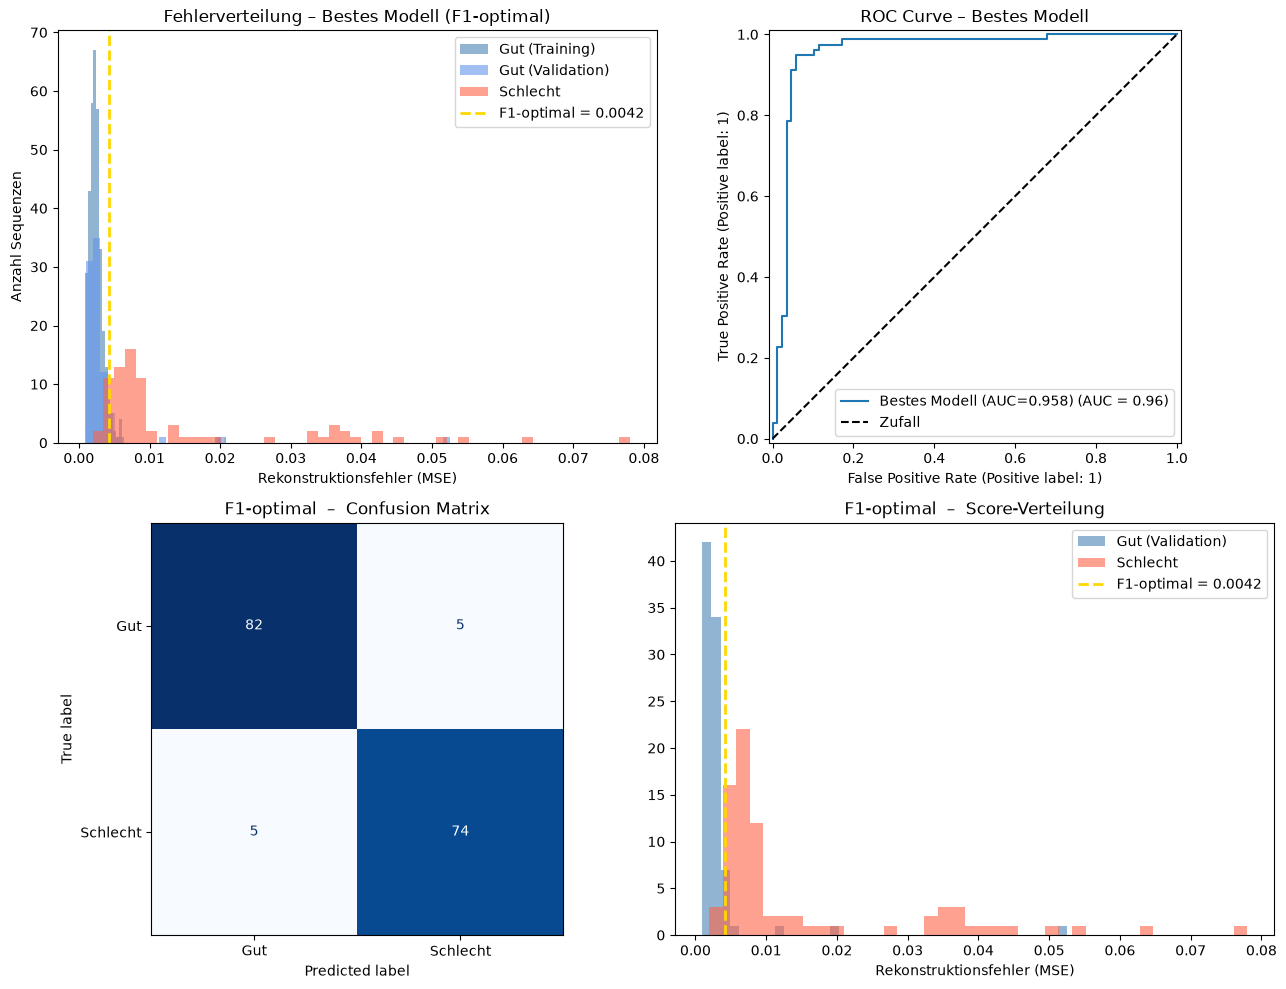

In [200]:
# Fehlerverteilung + Confusion Matrix fuer das beste Optuna-Modell (F1-optimal)
train_err_best = recon_err(best_model, X_train)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# --- Reihe 0: Fehlerverteilung ---
axes[0, 0].hist(train_err_best, bins=50, alpha=0.6, label='Gut (Training)',   color='steelblue')
axes[0, 0].hist(val_err_best,   bins=50, alpha=0.6, label='Gut (Validation)', color='cornflowerblue')
axes[0, 0].hist(bad_err_best,   bins=50, alpha=0.6, label='Schlecht',          color='tomato')
axes[0, 0].axvline(thr_f1_best, color='gold', linestyle='--', linewidth=2,
                   label=f'F1-optimal = {thr_f1_best:.4f}')
axes[0, 0].set_xlabel('Rekonstruktionsfehler (MSE)')
axes[0, 0].set_ylabel('Anzahl Sequenzen')
axes[0, 0].set_title('Fehlerverteilung – Bestes Modell (F1-optimal)')
axes[0, 0].legend()

# --- Reihe 0: ROC-Kurve ---
RocCurveDisplay.from_predictions(
    y_tr_best, y_sc_best,
    name=f'Bestes Modell (AUC={auc_best:.3f})',
    ax=axes[0, 1]
)
axes[0, 1].plot([0, 1], [0, 1], 'k--', label='Zufall')
axes[0, 1].set_title('ROC Curve – Bestes Modell')
axes[0, 1].legend()

# --- Reihe 1: Confusion Matrix + Score-Verteilung (F1-optimal) ---
ConfusionMatrixDisplay(
    confusion_matrix(y_tr_best, y_pred_best),
    display_labels=['Gut', 'Schlecht']
).plot(ax=axes[1, 0], colorbar=False, cmap='Blues')
axes[1, 0].set_title(f'F1-optimal  –  Confusion Matrix')

axes[1, 1].hist(val_err_best, bins=40, alpha=0.6, label='Gut (Validation)', color='steelblue')
axes[1, 1].hist(bad_err_best, bins=40, alpha=0.6, label='Schlecht',          color='tomato')
axes[1, 1].axvline(thr_f1_best, color='gold', linestyle='--', linewidth=2,
                   label=f'F1-optimal = {thr_f1_best:.4f}')
axes[1, 1].set_xlabel('Rekonstruktionsfehler (MSE)')
axes[1, 1].set_title('F1-optimal  –  Score-Verteilung')
axes[1, 1].legend()

plt.tight_layout()
plt.show()